In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('quick_commerce_data_raw.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (1000000, 13)

Columns: ['Order_ID', 'Company', 'City', 'Customer_Age', 'Order_Value', 'Delivery_Time_Min', 'Distance_Km', 'Items_Count', 'Product_Category', 'Payment_Method', 'Customer_Rating', 'Discount_Applied', 'Delivery_Partner_Rating']

Data Types:
 Order_ID                     int64
Company                        str
City                           str
Customer_Age                 int64
Order_Value                float64
Delivery_Time_Min          float64
Distance_Km                float64
Items_Count                float64
Product_Category               str
Payment_Method                 str
Customer_Rating            float64
Discount_Applied             int64
Delivery_Partner_Rating    float64
dtype: object

First 5 rows:
    Order_ID           Company      City  Customer_Age  Order_Value  \
0   1000001  Swiggy Instamart     Noida            46    702.33750   
1   1000002  Flipkart Minutes  Amritsar            56   1007.30000   
2   1000003  Flipkart Minutes    Mumbai   

In [2]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== NULL PERCENTAGE ===")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\n=== BASIC STATS ===")
print(df.describe())

=== NULL VALUES ===
Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

=== NULL PERCENTAGE ===
Order_ID                    0.00
Company                     0.00
City                        5.20
Customer_Age                0.00
Order_Value                 0.00
Delivery_Time_Min           0.00
Distance_Km                 0.00
Items_Count                 3.50
Product_Category            0.00
Payment_Method              0.00
Customer_Rating             4.70
Discount_Applied            0.00
Delivery_Partner_Rating    10.41
dtype: float64

=== BASIC STATS ===
           Order_ID    Customer_Age

In [3]:
# 1. Fill numeric nulls with median (safer than mean for skewed data)
df['Items_Count'] = df['Items_Count'].fillna(df['Items_Count'].median())
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].median())

# 2. Fill City nulls with 'Unknown'
df['City'] = df['City'].fillna('Unknown')

# 3. Fix the float mess (round noisy float columns to 2 decimal places)
float_cols = ['Order_Value', 'Delivery_Time_Min', 'Distance_Km', 'Customer_Rating', 'Delivery_Partner_Rating']
df[float_cols] = df[float_cols].round(2)

# 4. Items_Count should be integer
df['Items_Count'] = df['Items_Count'].astype(int)

# 5. Verify no nulls remain
print("=== NULLS AFTER CLEANING ===")
print(df.isnull().sum())

print("\n=== SAMPLE AFTER CLEANING ===")
print(df.head())

=== NULLS AFTER CLEANING ===
Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

=== SAMPLE AFTER CLEANING ===
   Order_ID           Company      City  Customer_Age  Order_Value  \
0   1000001  Swiggy Instamart     Noida            46       702.34   
1   1000002  Flipkart Minutes  Amritsar            56      1007.30   
2   1000003  Flipkart Minutes    Mumbai            18      1211.66   
3   1000004  Swiggy Instamart     Delhi            23      1179.06   
4   1000005             Dunzo    Mumbai            44       586.03   

   Delivery_Time_Min  Distance_Km  Items_Count Product_Category  \
0              19.18        11.97           12            Dair

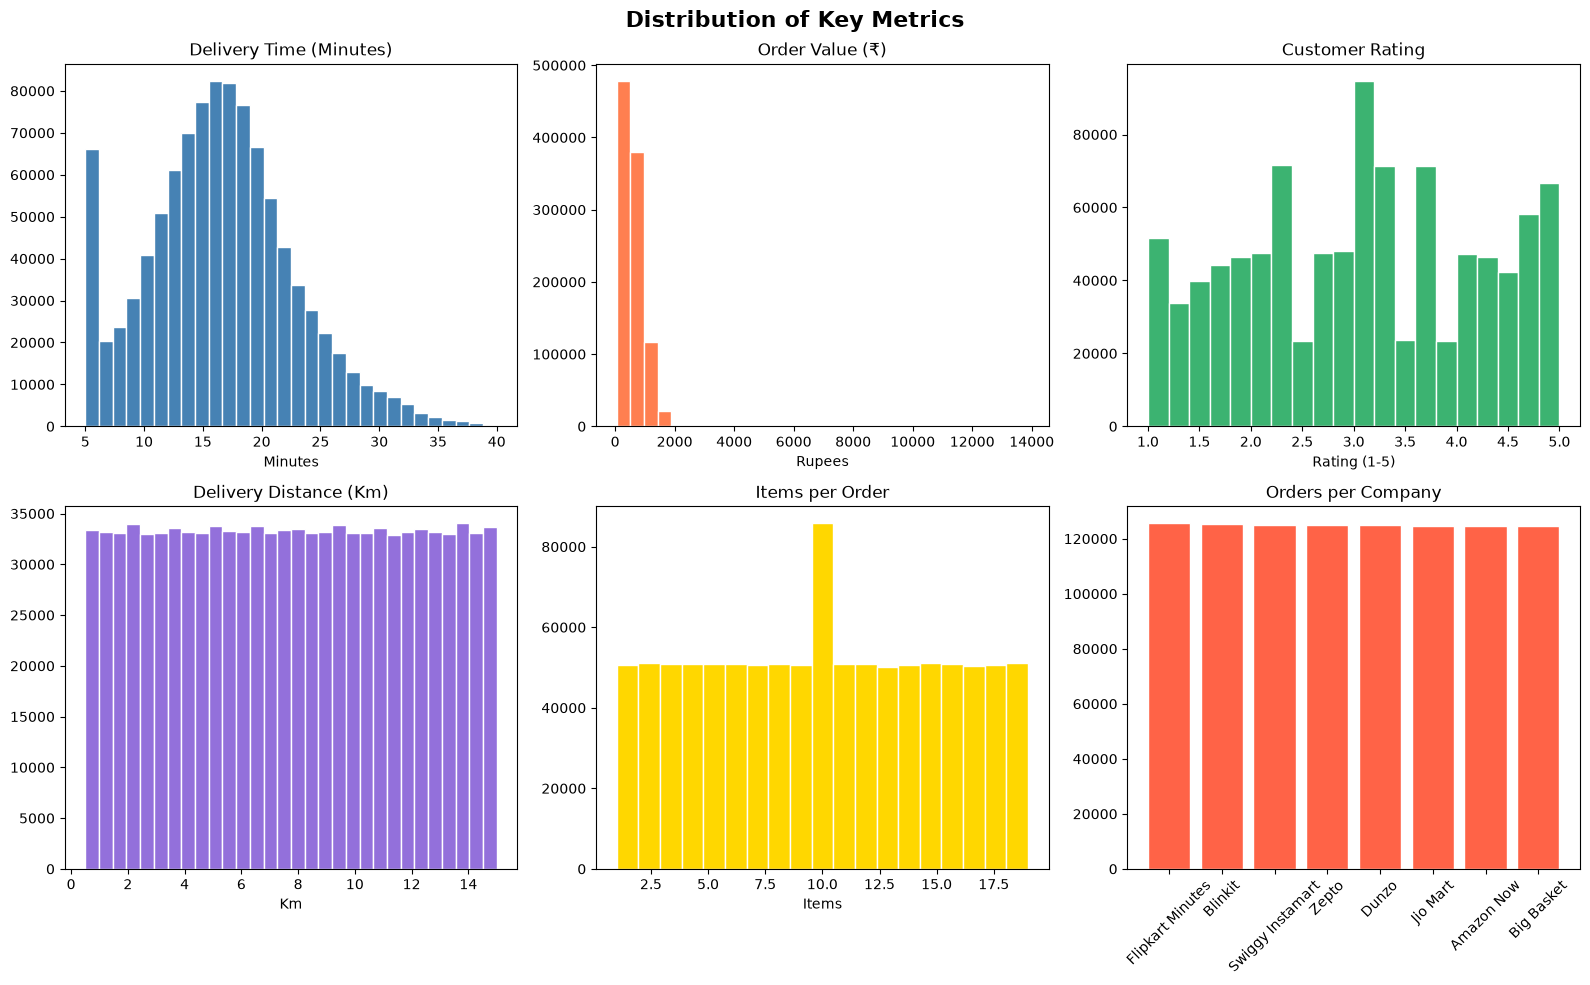

Chart saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Metrics', fontsize=16, fontweight='bold')

# 1. Delivery Time
axes[0,0].hist(df['Delivery_Time_Min'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Delivery Time (Minutes)')
axes[0,0].set_xlabel('Minutes')

# 2. Order Value
axes[0,1].hist(df['Order_Value'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Order Value (₹)')
axes[0,1].set_xlabel('Rupees')

# 3. Customer Rating
axes[0,2].hist(df['Customer_Rating'], bins=20, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Customer Rating')
axes[0,2].set_xlabel('Rating (1-5)')

# 4. Distance
axes[1,0].hist(df['Distance_Km'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Delivery Distance (Km)')
axes[1,0].set_xlabel('Km')

# 5. Items Count
axes[1,1].hist(df['Items_Count'], bins=19, color='gold', edgecolor='white')
axes[1,1].set_title('Items per Order')
axes[1,1].set_xlabel('Items')

# 6. Company order share
company_counts = df['Company'].value_counts()
axes[1,2].bar(company_counts.index, company_counts.values, color='tomato', edgecolor='white')
axes[1,2].set_title('Orders per Company')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('univariate_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

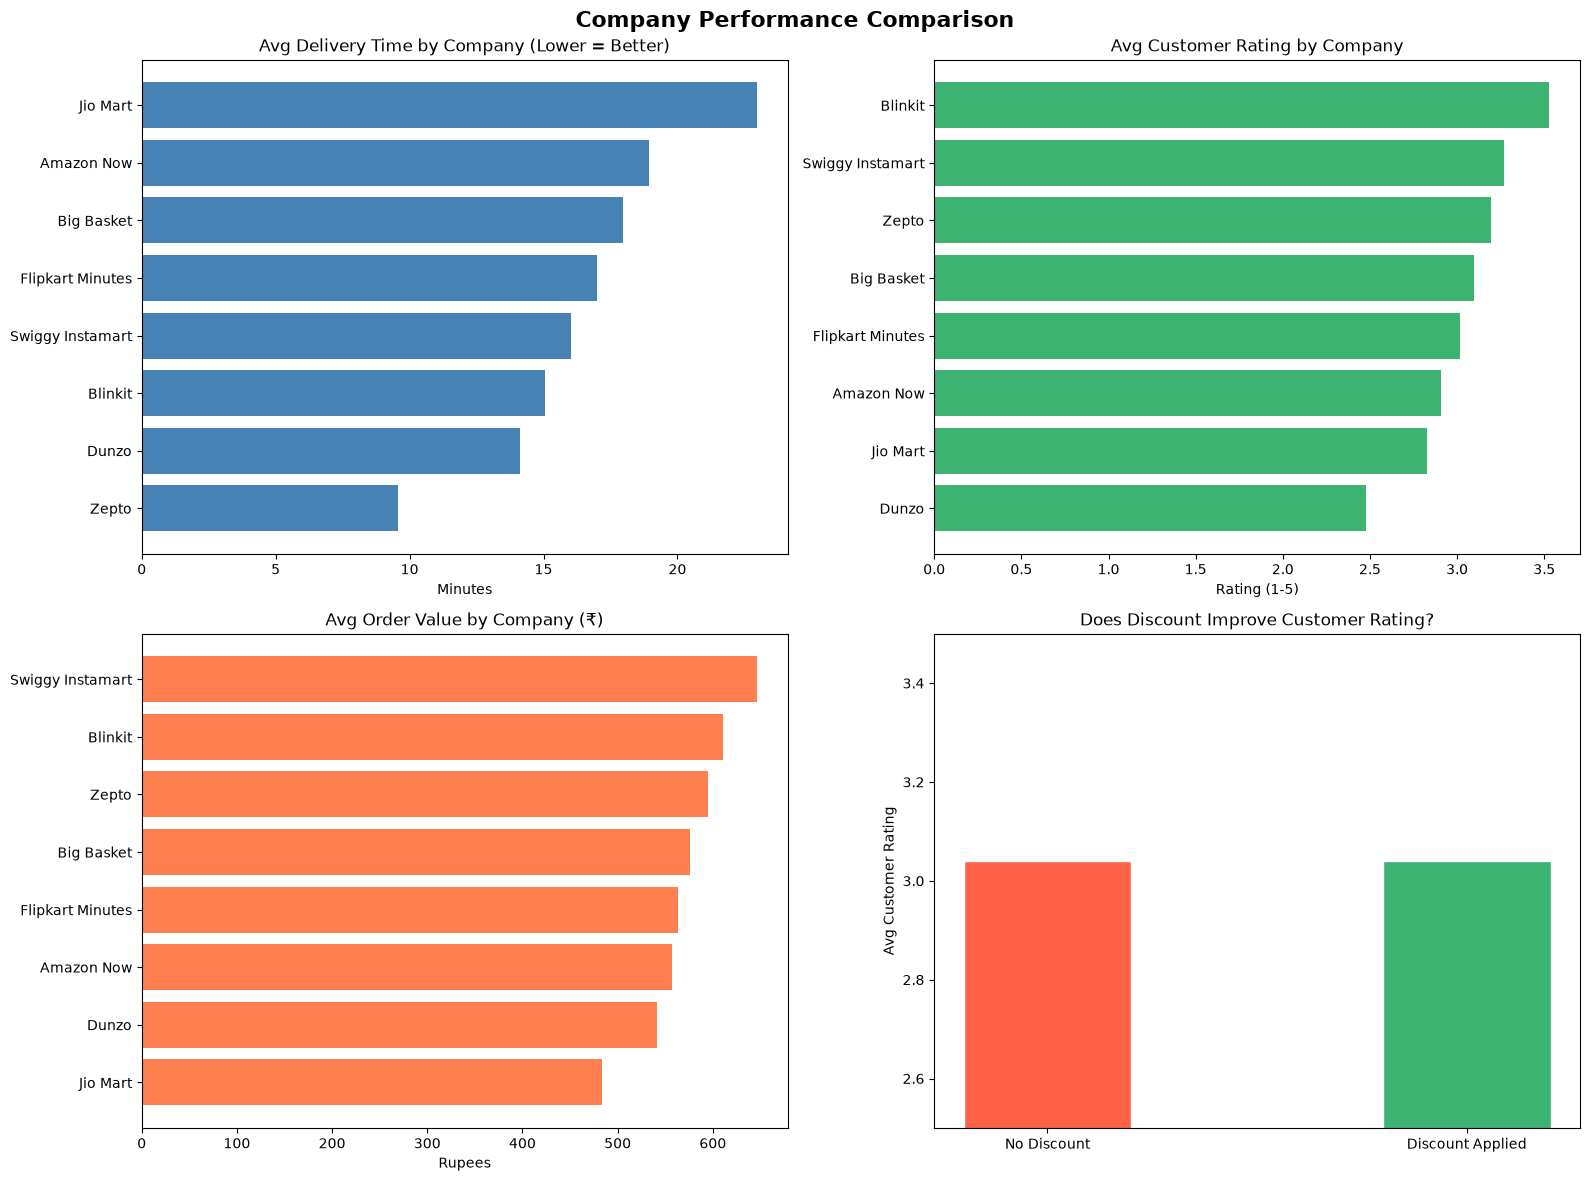

Done!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Company Performance Comparison', fontsize=16, fontweight='bold')

# 1. Average delivery time per company
avg_delivery = df.groupby('Company')['Delivery_Time_Min'].mean().sort_values()
axes[0,0].barh(avg_delivery.index, avg_delivery.values, color='steelblue')
axes[0,0].set_title('Avg Delivery Time by Company (Lower = Better)')
axes[0,0].set_xlabel('Minutes')

# 2. Average customer rating per company
avg_rating = df.groupby('Company')['Customer_Rating'].mean().sort_values()
axes[0,1].barh(avg_rating.index, avg_rating.values, color='mediumseagreen')
axes[0,1].set_title('Avg Customer Rating by Company')
axes[0,1].set_xlabel('Rating (1-5)')

# 3. Average order value per company
avg_order = df.groupby('Company')['Order_Value'].mean().sort_values()
axes[1,0].barh(avg_order.index, avg_order.values, color='coral')
axes[1,0].set_title('Avg Order Value by Company (₹)')
axes[1,0].set_xlabel('Rupees')

# 4. Discount impact on customer rating
discount_rating = df.groupby('Discount_Applied')['Customer_Rating'].mean()
axes[1,1].bar(['No Discount', 'Discount Applied'], discount_rating.values, 
               color=['tomato', 'mediumseagreen'], edgecolor='white', width=0.4)
axes[1,1].set_title('Does Discount Improve Customer Rating?')
axes[1,1].set_ylabel('Avg Customer Rating')
axes[1,1].set_ylim(2.5, 3.5)

plt.tight_layout()
plt.savefig('bivariate_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [6]:
print("=== Q1: Does faster delivery = better rating? ===")
corr = df['Delivery_Time_Min'].corr(df['Customer_Rating'])
print(f"Correlation between Delivery Time and Customer Rating: {corr:.3f}")

print("\n=== Q2: Which city has worst delivery performance? ===")
city_delivery = df[df['City'] != 'Unknown'].groupby('City')['Delivery_Time_Min'].mean().sort_values(ascending=False)
print(city_delivery)

print("\n=== Q3: Which product category gets lowest ratings? ===")
cat_rating = df.groupby('Product_Category')['Customer_Rating'].mean().sort_values()
print(cat_rating.round(2))

print("\n=== Q4: Company-wise summary table ===")
summary = df.groupby('Company').agg(
    Avg_Delivery_Time=('Delivery_Time_Min', 'mean'),
    Avg_Customer_Rating=('Customer_Rating', 'mean'),
    Avg_Order_Value=('Order_Value', 'mean'),
    Avg_Partner_Rating=('Delivery_Partner_Rating', 'mean'),
    Total_Orders=('Order_ID', 'count')
).round(2)
print(summary.sort_values('Avg_Customer_Rating', ascending=False))

=== Q1: Does faster delivery = better rating? ===
Correlation between Delivery Time and Customer Rating: -0.042

=== Q2: Which city has worst delivery performance? ===
City
Haridwar     27.541582
Jaipur       20.549046
Mumbai       17.511951
Bengluru     16.515320
Amritsar     15.568492
Pune         15.558815
Gurgaon      15.553254
Kolkata      15.534905
Chennai      15.534588
Hyderabad    15.533691
Noida        15.512752
Delhi         7.139341
Name: Delivery_Time_Min, dtype: float64

=== Q3: Which product category gets lowest ratings? ===
Product_Category
Household              3.04
Snacks                 3.04
Groceries              3.04
Beverages              3.04
Dairy                  3.04
Personal Care          3.04
Fruits & Vegetables    3.04
Name: Customer_Rating, dtype: float64

=== Q4: Company-wise summary table ===
                  Avg_Delivery_Time  Avg_Customer_Rating  Avg_Order_Value  \
Company                                                                     
Blinkit  

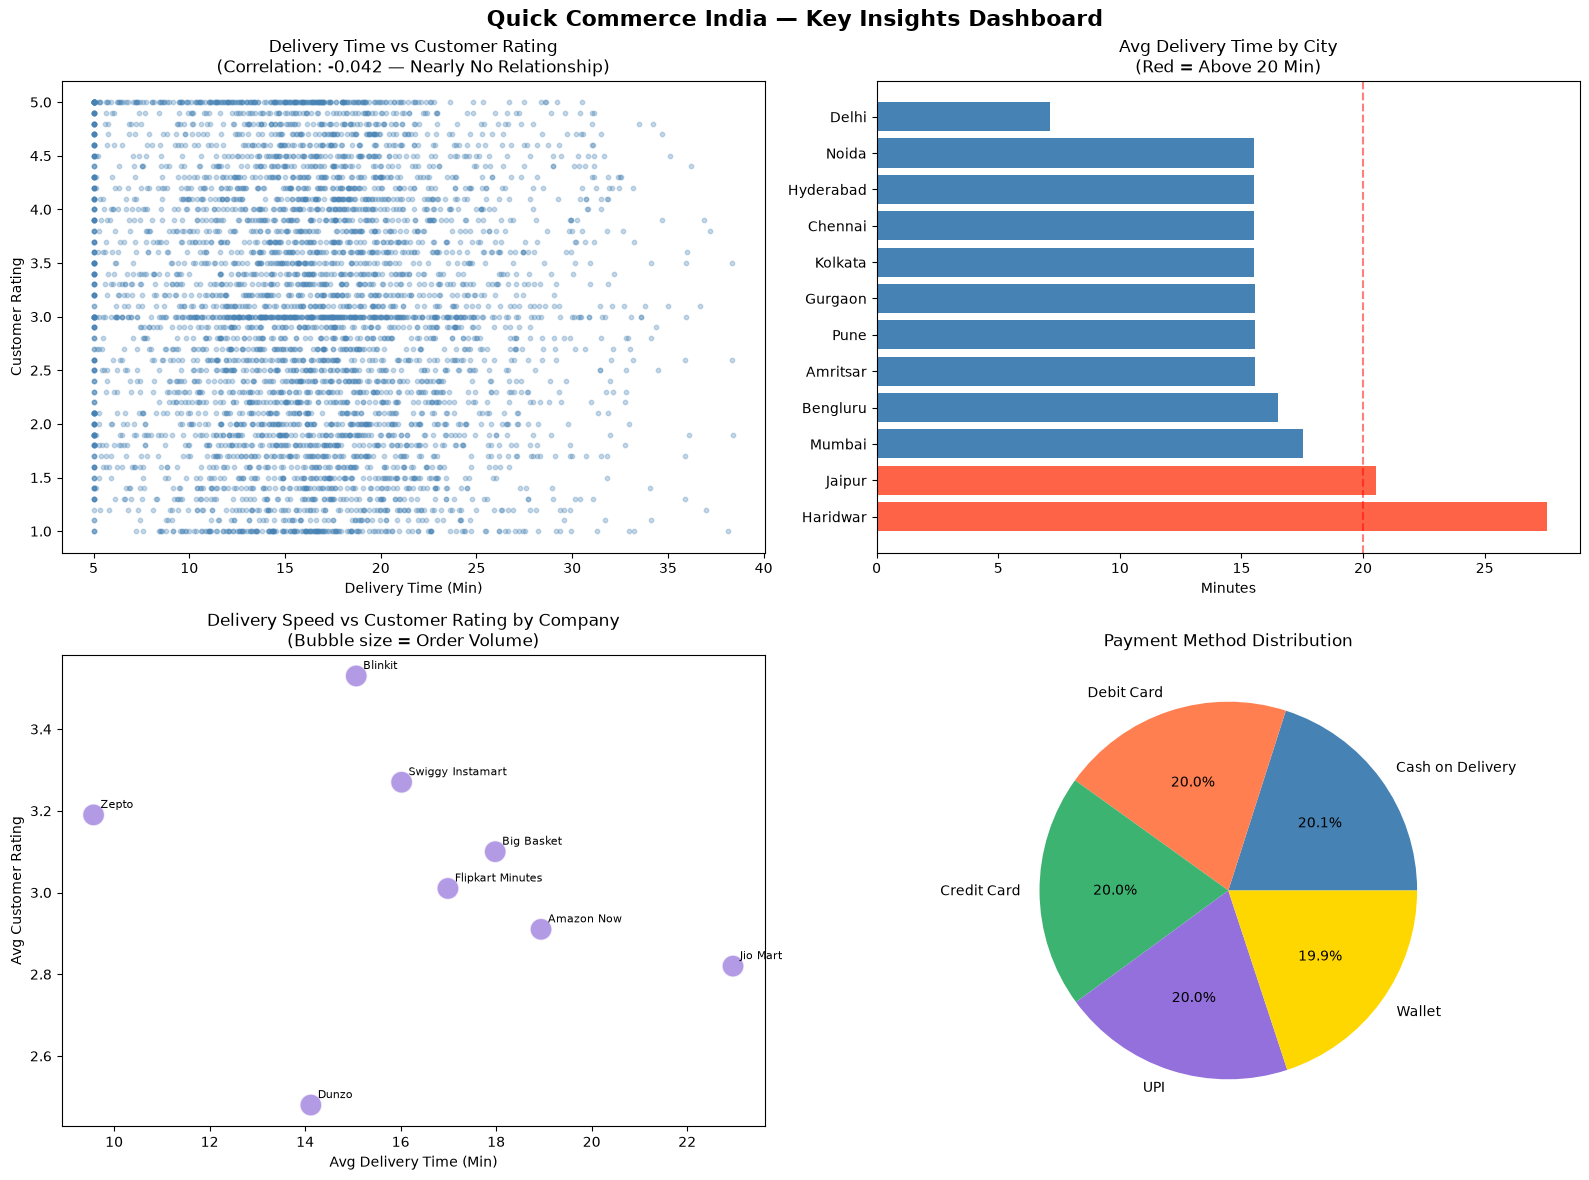

Dashboard saved!


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Quick Commerce India — Key Insights Dashboard', fontsize=16, fontweight='bold')

# 1. Delivery Time vs Customer Rating (scatter)
sample = df.sample(5000, random_state=42)
axes[0,0].scatter(sample['Delivery_Time_Min'], sample['Customer_Rating'], 
                  alpha=0.3, color='steelblue', s=10)
axes[0,0].set_title(f'Delivery Time vs Customer Rating\n(Correlation: -0.042 — Nearly No Relationship)')
axes[0,0].set_xlabel('Delivery Time (Min)')
axes[0,0].set_ylabel('Customer Rating')

# 2. City-wise avg delivery time (excluding Unknown)
city_data = df[df['City'] != 'Unknown'].groupby('City')['Delivery_Time_Min'].mean().sort_values(ascending=False)
colors = ['tomato' if x > 20 else 'steelblue' for x in city_data.values]
axes[0,1].barh(city_data.index, city_data.values, color=colors)
axes[0,1].set_title('Avg Delivery Time by City\n(Red = Above 20 Min)')
axes[0,1].set_xlabel('Minutes')
axes[0,1].axvline(x=20, color='red', linestyle='--', alpha=0.5)

# 3. Company — Delivery Time vs Rating bubble chart
x = summary['Avg_Delivery_Time'].values
y = summary['Avg_Customer_Rating'].values
sizes = summary['Total_Orders'].values / 500
companies = summary.index.tolist()

axes[1,0].scatter(x, y, s=sizes, alpha=0.7, color='mediumpurple', edgecolors='white')
for i, company in enumerate(companies):
    axes[1,0].annotate(company, (x[i], y[i]), textcoords="offset points", 
                       xytext=(5, 5), fontsize=8)
axes[1,0].set_title('Delivery Speed vs Customer Rating by Company\n(Bubble size = Order Volume)')
axes[1,0].set_xlabel('Avg Delivery Time (Min)')
axes[1,0].set_ylabel('Avg Customer Rating')

# 4. Payment method distribution
payment = df['Payment_Method'].value_counts()
axes[1,1].pie(payment.values, labels=payment.index, autopct='%1.1f%%', 
              colors=['steelblue','coral','mediumseagreen','mediumpurple','gold'])
axes[1,1].set_title('Payment Method Distribution')

plt.tight_layout()
plt.savefig('insights_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

# Quick Commerce India — EDA & Insights Report

## Dataset
- 1,000,000 orders across 8 Indian quick commerce platforms
- Cities: Delhi, Mumbai, Bengaluru, Hyderabad, and 8 others
- Columns: Delivery time, order value, ratings, category, payment method

## Data Quality Findings
- Delivery_Partner_Rating had highest missing values (10.4%) — filled with median
- City missing in 5.2% of records — filled with 'Unknown'
- Customer_Rating missing in 4.7% of records — filled with median
- Order_Value floats cleaned and rounded to 2 decimal places

## Key Business Insights

### 1. Speed does NOT drive customer satisfaction
Correlation between delivery time and customer rating is only -0.042 — 
nearly zero. Platforms cannot rely on speed alone to improve ratings.

### 2. Blinkit leads on customer satisfaction
Blinkit has the highest average customer rating (3.53) and a competitive 
delivery time (15 min). It is the best overall performer.

### 3. Swiggy Instamart attracts highest spending customers
Average order value of ₹646 — highest among all platforms — despite not 
being the fastest. Suggests strong brand trust and product variety.

### 4. Zepto is fastest but not highest rated
Zepto delivers in ~9.5 minutes (fastest) but ranks 3rd in customer rating. 
Speed alone is not enough to win customer loyalty.

### 5. Dunzo has a quality problem
Despite a decent delivery time (14 min), Dunzo has the lowest customer 
rating (2.48). Delivery speed is not the issue — service quality likely is.

### 6. Haridwar and Jaipur have slowest deliveries
Smaller cities with fewer dark stores result in 27.5 min and 20.5 min 
average delivery times — well above the 20 min threshold.

### 7. Discounts do not improve customer ratings
Orders with and without discounts show nearly identical average ratings. 
Platforms are spending on discounts without gaining customer satisfaction.

### 8. Payment methods are evenly distributed
All 5 payment methods (UPI, Wallet, Credit Card, Debit Card, Cash on 
Delivery) account for ~20% each — no single method dominates.

## Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook